# Get AustinTX Data into pkl and pgk pkl

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['figure.dpi'] = 125

# --- helper functions for loading/processing ERCOT data ---

def convert_ts_02to16(r):
    """converts timestamp string to datetime index for the years 2002 to 2016"""
    t=str(r.year)+'-'+str(r.month)+'-'+str(r.day)+' '
    if r.minute > 30:
        t += str(r.hour)
    else:
        t += str(r.hour - 1)
    t += ':0'
    return pd.to_datetime(t)

def convert_ts_17(r):
    """converts timestamp string to datetime index for the year 2017"""
    h = int(str(r)[11:13])-1
    if h < 10:
        return pd.to_datetime(str(r)[:11]+'0'+str(h)+str(r)[13:])
    else:
        return pd.to_datetime(str(r)[:11]+str(h)+str(r)[13:])
    
def process_02to16(filename, load_col):
    """loads excel data into dataframe for the years 2002 to 2016"""
    df=pd.read_excel(filename, usecols='A,'+load_col, names=['time','load'])
    df['time'] = df['time'].apply(convert_ts_02to16)
    return df

def process_17(filename, load_col):
    """loads excel data into dataframe for the year 2017"""
    df=pd.read_excel(filename, usecols='A,'+load_col, names=['time','load'])
    df['time'] = df['time'].apply(convert_ts_17)
    return df

/var/tmp/pbs.4885334.sawtoothpbs/ipykernel_32000/347782436.py:24: FutureWarning: Parsed string "11/05/2017 01:00 DST" included an un-recognized timezone "DST". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  return pd.to_datetime(str(r)[:11]+'0'+str(h)+str(r)[13:])
/var/tmp/pbs.4885334.sawtoothpbs/ipykernel_32000/347782436.py:24: FutureWarning: Parsed string "11/04/2018 01:00 DST" included an un-recognized timezone "DST". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  return pd.to_datetime(str(r)[:11]+'0'+str(h)+str(r)[13:])
/var/tmp/pbs.4885334.sawtoothpbs/ipykernel_32000/347782436.py:24: FutureWarning: Parsed string "11/03/2019 01:00 DST" included an un-recognized timezone "DST". Dropping unrecognized 

,load
time,
2002-01-01 00:00:00,4793.193560
2002-01-01 01:00:00,4766.918187
2002-01-01 02:00:00,4702.918892
2002-01-01 03:00:00,4669.064391
2002-01-01 04:00:00,4695.011904


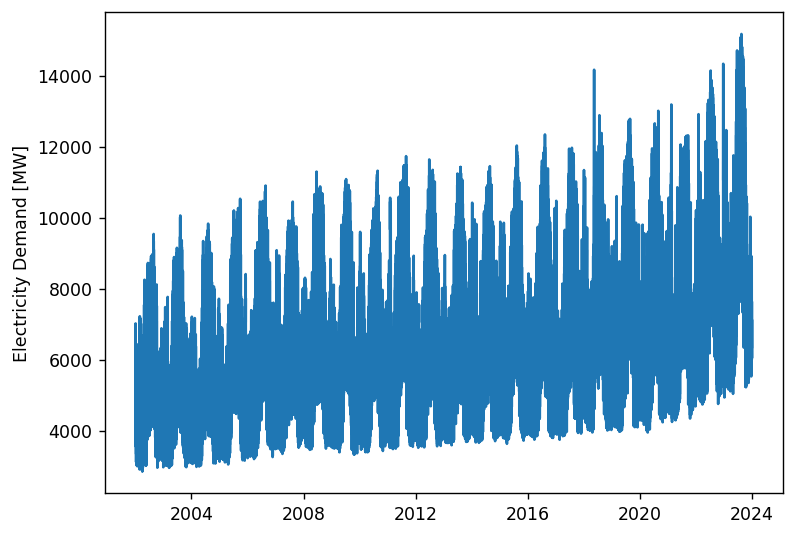

In [2]:
# setup list of filenames
path = '/home/lambpc/AMARANTH/opensourcegridmodeling/ElectricityDemandAustinTX/ercot_data/'
suffix_02to14 = '_ercot_hourly_load_data.xls'
fname_15 = 'native_Load_2015.xls'
filenames = []
for year in range(2002, 2015):
    filenames.append(path + str(year) + '_ercot_hourly_load_data.xls')
filenames.append(path + 'native_Load_2015.xls')
for year in range(2016, 2024):
    filenames.append(path + 'native_Load_' + str(year) + '.xlsx')

# load each file into a dataframe
df_list = []
year = 2002
for filename in filenames:
    if year < 2017:
        df_list.append(process_02to16(filename, 'H'))
    else:
        df_list.append(process_17(filename, 'H'))
    year += 1
        
# combine into one dataframe and set datetime index
ercot_df = pd.concat(df_list)
ercot_df.set_index('time', inplace=True)

# fix missing/duplicate values
ercot_df = ercot_df.groupby('time').mean()
ercot_df = ercot_df.asfreq('H', method='pad')

# plot and show first 5 rows
plt.plot(ercot_df['load'])
plt.ylabel('Electricity Demand [MW]')
ercot_df.head()

In [3]:
ercot_df

,load
time,
2002-01-01 00:00:00,4793.193560
2002-01-01 01:00:00,4766.918187
2002-01-01 02:00:00,4702.918892
2002-01-01 03:00:00,4669.064391
2002-01-01 04:00:00,4695.011904
...,...
2023-12-31 19:00:00,6972.382083
2023-12-31 20:00:00,6742.135888
2023-12-31 21:00:00,6518.290964


In [4]:
ercot_df = ercot_df.rename(columns={'time':'start_time', 'load' : 'tensor'})

In [5]:
import pickle
import zipfile
import pgzip
import os

In [6]:
path = os.getcwd()

In [11]:
import datetime
import torch
tensor = torch.from_numpy(ercot_df['tensor'].values)
dict = {'start_time' : datetime.datetime(2002,1,1,0,0, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=64800))), 'tensor' : tensor}

In [12]:
with open('/home/lambpc/AMARANTH/opensourcegridmodeling/Transformer/code/code/Datasets/AustinTX/austin_dict.pkl','wb') as f :
    pickle.dump(dict,f)

In [13]:
with open(os.path.join(path,'Datasets/AustinTX/austin_dict.pkl'),'rb') as f :
    sd = pickle.load(f)

In [14]:
with pgzip.open(os.path.join(path,'Datasets/AustinTX/austin_dict.pkl.pgz'), 'wb') as f:
            pickle.dump(sd,f)

In [15]:
ercot_df.to_csv(os.path.join(path,'Datasets/AustinTX/austin_dict.csv'))